# 군집화 요약본

## 1. 군집화(Clustering)

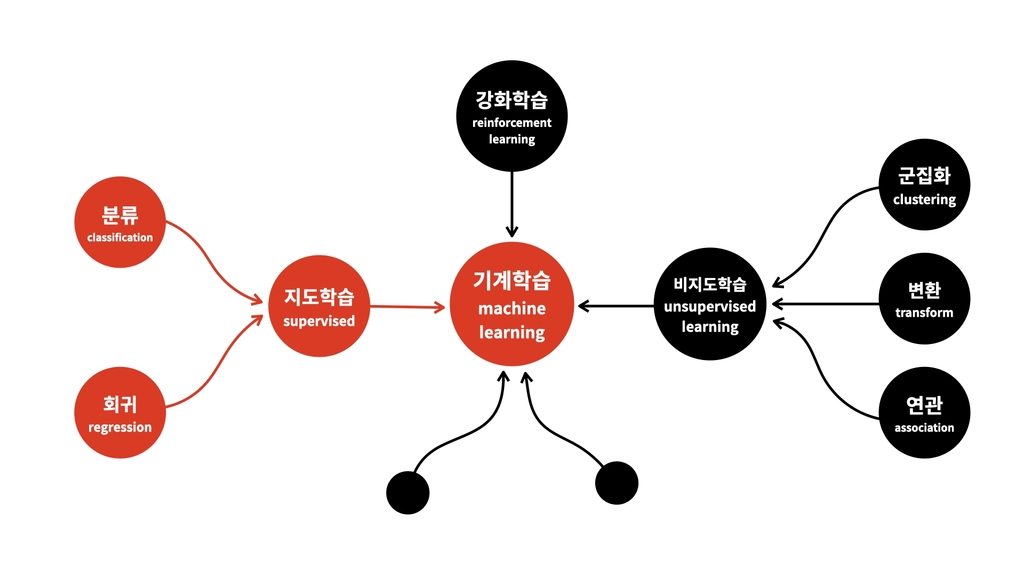

### 머신러닝: 비지도학습

**1) 특징**
- 정답 레이블이 없으므로 에이전트가 해야 하는 작업이 명확히 정의되지 않으며, 모델의 성능을 명확히 측정하기 어려움
- 목표가 명확하게 정의된 구체적이고 좁은 범위의 문제에는 지도학습보다 불리할 수 있으나, 목표 자체가 명확하지 않고 데이터에서 새로운 특성을 찾는 목적에는 적합함

**2) 적합한 case**
- 패턴이 아직 알려지지 않은 경우 (정답을 아직 알 수 없음)
- 패턴이 계속해서 변하는 경우 (정답을 익혀도 의미가 없음)
- 열린 문제를 해결하고 지식을 일반화해야 하는 경우

### 군집화란?

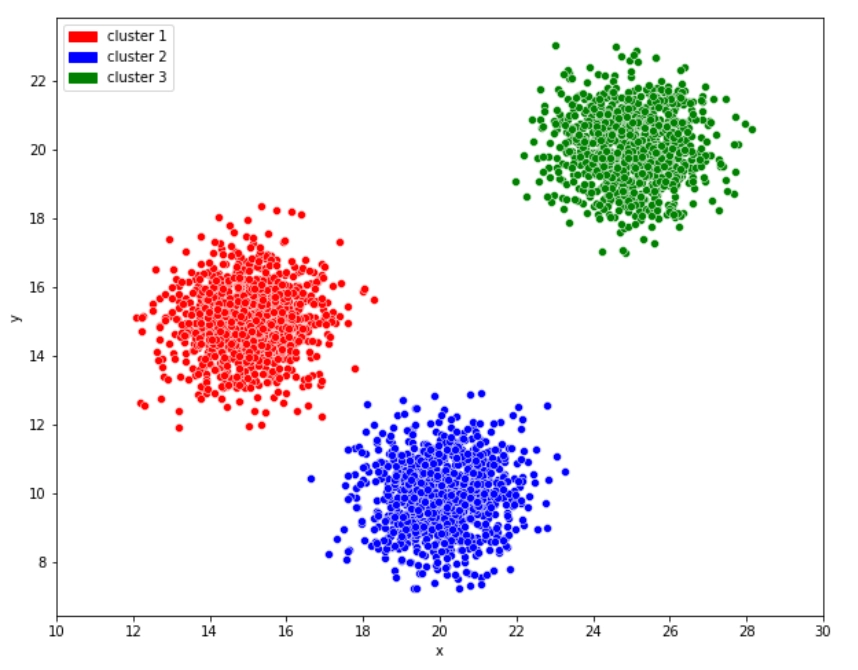

**1) 개념**
- 군집화: 데이터를 비슷한 특성을 가진 그룹(군집)으로 나누는 비지도학습 기법
- 군집: 유사한 데이터들의 집합으로, 서로 다른 군집에 속한 개체들은 비슷하지 않아야 함

**2) 지도학습과 군집화의 차이**
- 지도학습: 독립변수와 종속변수 사이의 관계에서 패턴을 찾아 종속변수를 예측하는 구조
- 군집화: 종속변수를 설정하지 않고, 데이터 내부의 패턴을 인식해 유사성을 가진 그룹으로 나눔

> 사전에 정해진 목표 없이 데이터셋에 존재하는 고유한 패턴을 발견하고 추출하기 때문에 비지도학습으로 분류

**3) 군집화의 목표**

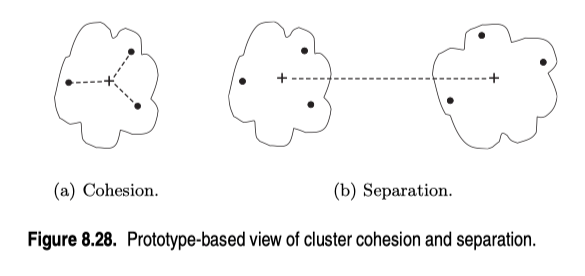
- 응집도(cohesion) 최대화: 같은 군집에 속하는 데이터끼리는 최대한 비슷하도록 함
- 분리도(separation) 최대화: 서로 다른 군집은 최대한 분리되도록 함

> 데이터 간의 유사성을 최대한 잘 유지하면서 서로 다른 그룹은 구분될 수 있도록 만드는 것

### 군집화 과정

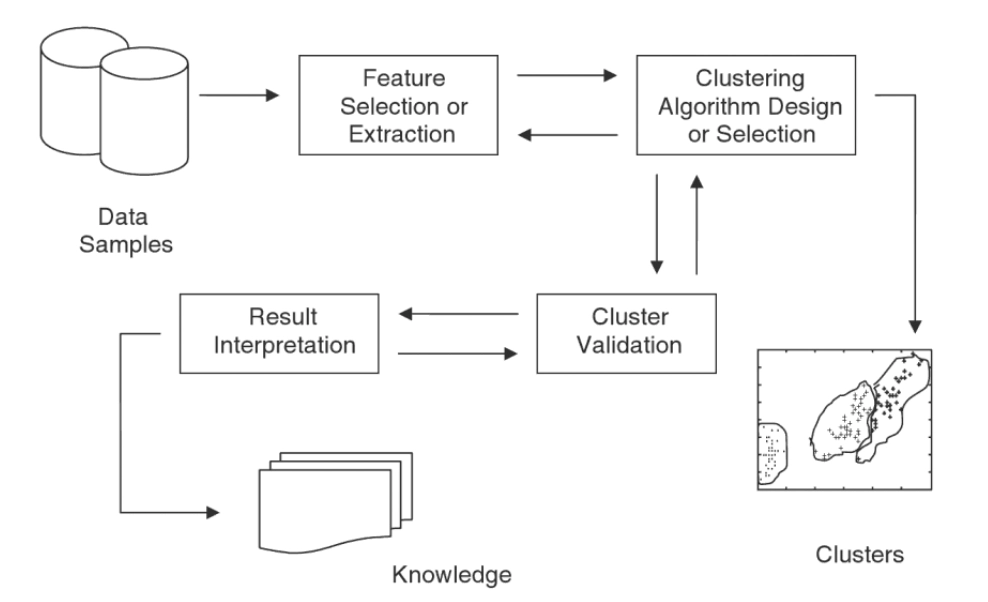

| 단계 | 내용 |
|---|---|
| 1. 피처 선택 또는 추출 | 군집화에 사용할 데이터의 피처(특징)를 선택 |
| 2. 군집화 알고리즘 선택 | 데이터의 특성과 목표에 따라 적합한 알고리즘을 선택 |
| 3. 군집 유효성 검증 | 군집화가 얼마나 잘 되었는지 평가 |
| 4. 결과 해석 | 각 군집이 지닌 특성 분석 및 해석 |

## 2. 군집화를 위한 데이터 준비

### 2-1. 군집화의 주요 고려사항

**1) 변수 유형 이해**
- 군집화에 사용될 피처의 종류와 특성을 명확하게 이해해야 함
- 변수 종류가 연속형 또는 명목형인지에 따라 적합한 군집화 알고리즘이 달라짐

**2) 거리 / 유사도 정의와 측정**
- 군집화는 데이터 간의 거리(distance) 또는 유사도(similarity)를 기반으로 그룹을 형성
- 변수 유형에 따라 적합한 거리 측정 방식이 다르기 때문에 정의가 중요

**3) 차원 축소**
- 변수가 많아질수록 모델이 복잡해지고, 효율성과 성능이 떨어짐
- 유사한 변수를 통합하거나 필요 없는 변수를 제거해 변수 개수를 줄일 수 있음

### 2-2. 변수 유형 이해

- 변수 유형에 따라 적합한 거리 측정 방법과 군집화 알고리즘이 달라짐

**1) 변수 유형**

| 유형 | 특징 | 거리 측정 | 적합한 알고리즘 | 주의사항 및 처리 방법 |
|---|---|---|---|---|
| 연속형 변수 (Continuous Variables) | 키, 몸무게, 나이, 소득 등 수치로 측정 가능한 변수 | 유클리디안 거리, 맨하탄 거리 등 | K-means, 계층적 군집화 등 | 스케일링 필수 (단위가 다르면 큰 값의 변수가 지배적 영향) |
| 명목형 변수 (Categorical Variables) | 성별, 지역, 직업 등 범주로 구분되는 변수 | 해밍 거리(Hamming distance), 자카드 거리 등 | K-modes, 계층적 군집화(특별한 거리 함수 사용) | 원-핫 인코딩 또는 더미 변수 변환 |
| 혼합형 변수 (Mixed Variables) | 연속형과 명목형이 섞인 데이터 | 각 변수 유형에 맞는 거리 함수를 조합하여 사용 | K-prototypes, Gower distance 기반 계층적 군집화 | 각 변수 유형에 맞는 거리 함수를 조합하여 사용 |

**2) 유형별 거리 측정 방법 및 알고리즘이 달라지는 이유**

**(1) 거리**
| 변수 유형 | 다른 이유 | 측정 방식 | 설명 |
|---|---|---|---|
| 연속형 | 순서가 있고, 간격이 의미 있음 | 유클리디안 거리, 맨하탄 거리 등 | 거리를 잰다는 건 결국 두 값을 뺀 다음 얼마나 차이 나는지 보는 것. 예: 나이 25 vs 27 → 2살 차이 |
| 명목형 | 순서가 없고, 간격도 의미 없음 | 해밍 거리, 자카드 거리 | 서울=1, 부산=2, 대구=3으로 바꿔 유클리디안 거리를 재면 서울↔부산 거리=1, 서울↔대구 거리=2가 되어 없던 순서와 간격이 생겨버림. 따라서 몇 개 항목이 다른가, 얼마나 겹치는가를 세는 방식을 사용 |
| 혼합형 | 연속형과 명목형을 하나의 자로 재질 못함 | Gower distance | 변수마다 다른 자를 쓰고 그 결과를 가중평균 냄 |

*다만 연속형의 경우 변수별 단위가 다르면 큰 값의 변수가 거리를 지배하기 때문에 스케일링 필수*


**(2) 알고리즘**
| 변수 유형 | 다른 이유 | 적합한 알고리즘 | 계산 방식 | 설명 |
|---|---|---|---|---|
| 연속형 | 평균이 의미 있는 변수 | K-means | 평균 | K-means는 군집의 중심점을 평균으로 계산함. 따라서 평균이 정의되는 연속형 변수에 적합 |
| 명목형 | 평균이 의미가 없음 | K-modes | 최빈값 | 평균 대신 가장 자주 등장하는 값을 사용. ex. 이 군집에서 가장 흔한 지역은 서울 |
| 혼합형 | 연속형과 명목형이 함께 존재함 | K-prototypes | 연속형은 평균, 명목형은 최빈값 | 연속형에는 평균, 명목형에는 최빈값을 각각 사용해 두 방식을 결합 |
| 연속형 / 명목형 | 하나의 중심점 계산 방식에 의존하지 않음 | 계층적 군집화 | 거리 기반 | 중심점을 직접 계산하기보다 데이터 간 거리를 기반으로 군집을 형성. 변수 유형에 맞는 거리 함수를 선택해 적용 |

### 2-3. 거리 / 유사도 정의와 측정

- 거리 측정 방법: 군집화에서 데이터 포인트나 군집 간의 유사성/비유사성을 수치로 계산하는 방법
- 거리가 가까울수록 유사, 거리가 멀수록 다르다고 판단

**1) 유클리디안 거리 (Euclidean Distance)**

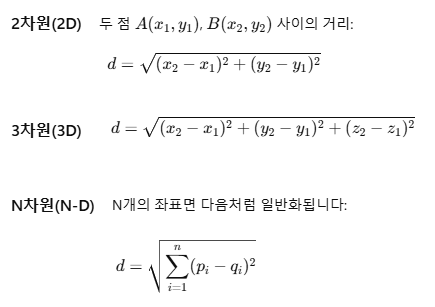
- 가장 일반적인 거리 측정 방법
- 두 점 사이의 직선거리를 의미
- K-means에서 기본적으로 사용

**2) 맨해튼 거리**

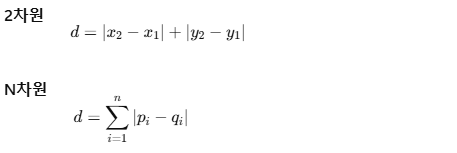

- 각 차원의 차이의 절댓값의 합
- 이상치에 덜 민감

**3) 코사인 유사도**

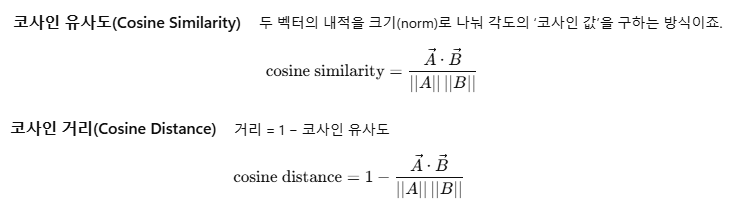
- 벡터 간의 각도를 측정
- 텍스트 데이터나 고차원 데이터에 효과적

### 2-4. 차원 축소

**1) 차원의 저주**

- 군집화 알고리즘은 거리 기반 알고리즘인 경우가 많기 때문에, 데이터의 차원이 높아질수록 문제가 발생할 수 있음
- 차원의 저주: 피처 공간이 너무 커져 알고리즘이 데이터를 효과적·효율적으로 훈련할 수 없는 현상
- 고차원일수록 공간이 폭발적으로 증가하고 데이터는 그대로이기 때문에, 데이터 포인트들이 서로 멀어지고 거리 기반 알고리즘의 분별력이 감소

**2) 왜 분별력이 사라지는가**

**① 공간은 폭발적으로 늘어나지만 데이터는 그대로**
| 차원 | 칸 수 | 칸당 데이터 | 상태 |
|---|---|---|---|
| 1차원 | 10 | 100개 | 빽빽함 |
| 2차원 | 100 | 10개 | 아직 괜찮음 |
| 3차원 | 1,000 | 1개 | 칸당 딱 하나 |
| 4차원 | 10,000 | 0.1개 | 열에 아홉은 빈칸 |
| 6차원 | 1,000,000 | 0.001개 | 사실상 전부 빈칸 |

- 차원이 하나 늘 때마다 공간이 10배씩 커짐
- 그 결과 모든 점이 텅 빈 공간에 혼자 떨어져 있게 됨

**② 가까운 점과 먼 점의 차이가 없어짐**
| 차원 | 최근접 거리 | 최원점 거리 | 몇 배 차이? |
|---|---|---|---|
| 2 | 0.02 | 1.01 | 61배 |
| 3 | 0.06 | 1.21 | 21배 |
| 10 | 0.49 | 1.88 | 3.8배 |
| 50 | 2.08 | 3.56 | 1.7배 |
| 100 | 3.36 | 4.75 | 1.4배 |
| 1000 | 12.14 | 13.58 | 1.1배 |
- 차원이 높아질수록 가장 가까운 점과 가장 먼 점의 거리 차이가 줄어듦
- 거리 기반 알고리즘의 분별력이 감소

**③ 쓸데없는 피처는 노이즈를 더함**
- 유클리디안 거리는 모든 차원의 차이를 전부 더함
- 관련 없는 피처가 많이 추가되면 그 피처들의 무작위 차이가 모두 더해져 군집이 모호해짐

**3) 차원 축소**
- 차원 축소(dimensionality reduction)에서 차원은 변수의 개수를 의미
- 차원 축소: 변수의 개수를 줄이는 것
- 목표: 고차원 데이터를 저차원 공간에 투영하면서도 핵심 정보는 가능한 지켜내는 것

**(1) 선형 투영**
- 고차원 공간에서 저차원 공간으로 데이터를 선형적으로 투영
- PCA, SVD, 랜덤 투영 등


**(2) 매니폴드 학습**
- 유클리드 거리가 아니라 데이터 포인트 사이의 곡선 거리를 고려하면서 학습하는 비선형 차원 축소
- t-SNE, UMAP, Isomap 등

**4) PCA**

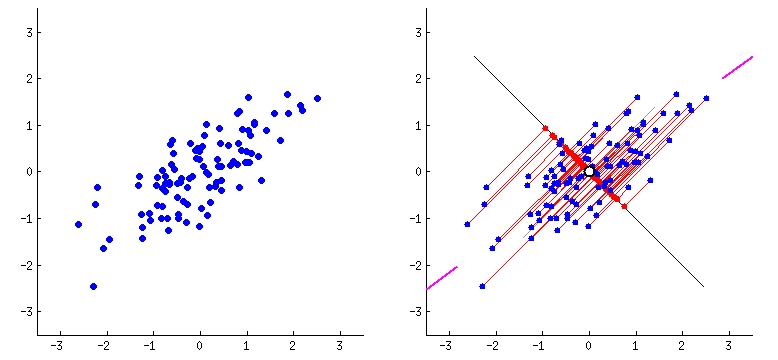

① 핵심 목적
- 다차원 데이터에서 가장 정보량, 즉 분산이 큰 방향을 찾고, 그 방향을 기준으로 데이터를 투영하여 차원을 줄이는 것

② 작동 원리
- 상관관계가 높은 피처들을 결합하고 상관관계가 없는 더 적은 수의 피처로 데이터를 표현
   - 원본의 고차원 데이터에서 최대 분산 방향을 찾고, 그 방향을 기준으로 저차원 공간에 투영
   - 이렇게 새로 파생된 성분을 주성분(Principal Component)이라고 함

③ 주의사항
| 구분 | 내용 |
|---|---|
| 표준화 필수 | PCA 사용 전 반드시 데이터 표준화 수행, 단위가 큰 변수의 영향이 과도해지는 것을 방지 |
| 결측값 처리 | 결측값이 있으면 PCA를 바로 사용할 수 없음 |
| 해석의 어려움 | 주성분은 원본 피처들의 조합이기 때문에 직관적으로 해석하기 어려움 |
| 정보 손실 | 차원을 줄이는 과정에서 일부 정보가 손실됨 |

## 3. 군집화 알고리즘

### 3-1. 계층적 군집화(Hierarchical Clustering)
- 정의
   - 가장 가까운 것부터 둘씩 차례로 합쳐 나가면서, 무엇이 언제 뭉쳤는지를 나무 모양(덴드로그램)으로 기록하는 군집화 방법
- 특징
   - 계층적 군집화 알고리즘은 데이터셋의 관측치를 사용해 덴드로그램을 만듬
   - 군집의 개수를 사전에 설정하지 않고, 클러스터링이 종료된 후에 원하는 군집의 개수를 선택할 수 있음
   - 트리 구조를 상향식으로 구성하냐, 하향식으로 구성하냐에 따라 응집형과 분리형으로 구분

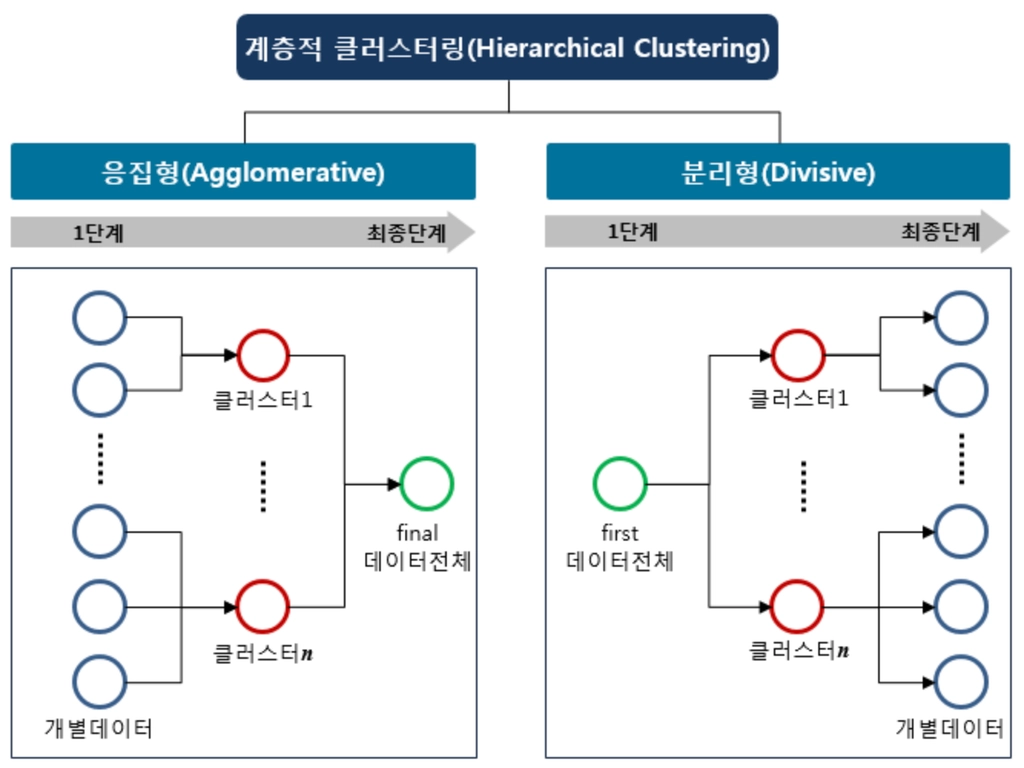

**1) 응집형 클러스터링**
- 각 샘플이 독립적인 클러스터로 시작. 하나만 남을 때까지 가장 가까운 클러스터를 병합


**2) 분할형 클러스터링**
- 전체를 포함하는 하나의 클러스터에서 시작해, 유사성이 낮은 데이터를 더 작은 클러스터로 나눔

**3) 과정**
| 단계 | 내용 |
|---|---|
| 1. 거리 행렬 계산 | 모든 데이터 포인트 간의 거리를 계산 |
| 2. 단일 클러스터 시작 | 각 데이터 포인트를 개별 클러스터로 초기화 |
| 3. 가장 가까운 클러스터 병합 | 정의된 기준에 따라 가장 가까운 두 클러스터를 병합 |
| 4. 거리 행렬 업데이트 | 새 클러스터와 나머지 간 거리를 다시 계산 |
| 5. 반복 | 모두 하나의 클러스터가 될 때까지 3, 4를 반복 |

**4) 6가지 연결 방법**

**(1) Single linkage (단일 연결법 / 최단 연결법)**
- 군집 A와 B 사이의 가장 가까운 두 점 간 거리로 군집 간 거리를 정의
- 고립된 군집을 찾는데 중점
- 이상치에 취약함

**(2) Complete linkage (완전 연결법 / 최장 연결법)**
- 군집 A와 B 사이의 가장 먼 두 점 간 거리로 군집 간 거리 정의
- 군집들의 내부 응집성에 중점을 둔 방법
- 최단 연결법과 마찬가지로 이상치에 민감함

**(3) Average linkage (평균 연결법)**
- 군집 A와 B의 모든 점 쌍 사이 거리의 평균
- 모든 항목에 대한 거리 평균을 구함
- 최단·최장 연결법보다 이상치에 덜 민감
- 계산량이 많아질 수 있다는 단점

**(4) Centroid Method (중심 연결법)**
- 각 군집의 중심점(centroid) 간의 거리
- 두 군집의 중심 간의 거리를 측정
- 중심을 계산해야 하므로 시간이 오래 걸림
- 덴드로그램에서 거리 축이 줄어드는 inversion이 발생할 수 있음

**(5) Median (중앙 연결법)**
- 두 군집의 중앙값 사이의 거리
- 두 군집의 중심점 사이 산술적 중간 지점을 새로운 대표값으로 설정
- 극단값에 영향을 덜 받음
- 기하학적 구조를 파악하기는 어려움

**(6) Ward's Procedure (Ward 연결법)**
- 군집 내 제곱합(SSE)이 가장 적게 증가하도록 병합
- 병합 후 군집 내 SSE 증가분이 최소인 것을 선택
- 실무에서 가장 무난하게 쓰이는 기본값

**5) 장단점**
- 장점 
   - k를 미리 정하지 않아도 됨
   - 데이터의 구조 전체가 눈에 보임
   - 다양한 유형의 데이터에 적용 가능
   - 결과가 항상 같음

- 단점
   - 느리고 메모리를 많이 사용함
   - 한 번 합치면 되돌릴 수 없음
   - 이상치에 민감함
   - 자를 높이를 사람이 정해야 함

### 3-2. K-means

- k-means: 데이터를 정해진 개수(K)의 그룹으로 나누되, 각 그룹의 중심점(centroid)과의 거리가 가장 가까운 데이터끼리 묶는 군집화 알고리즘

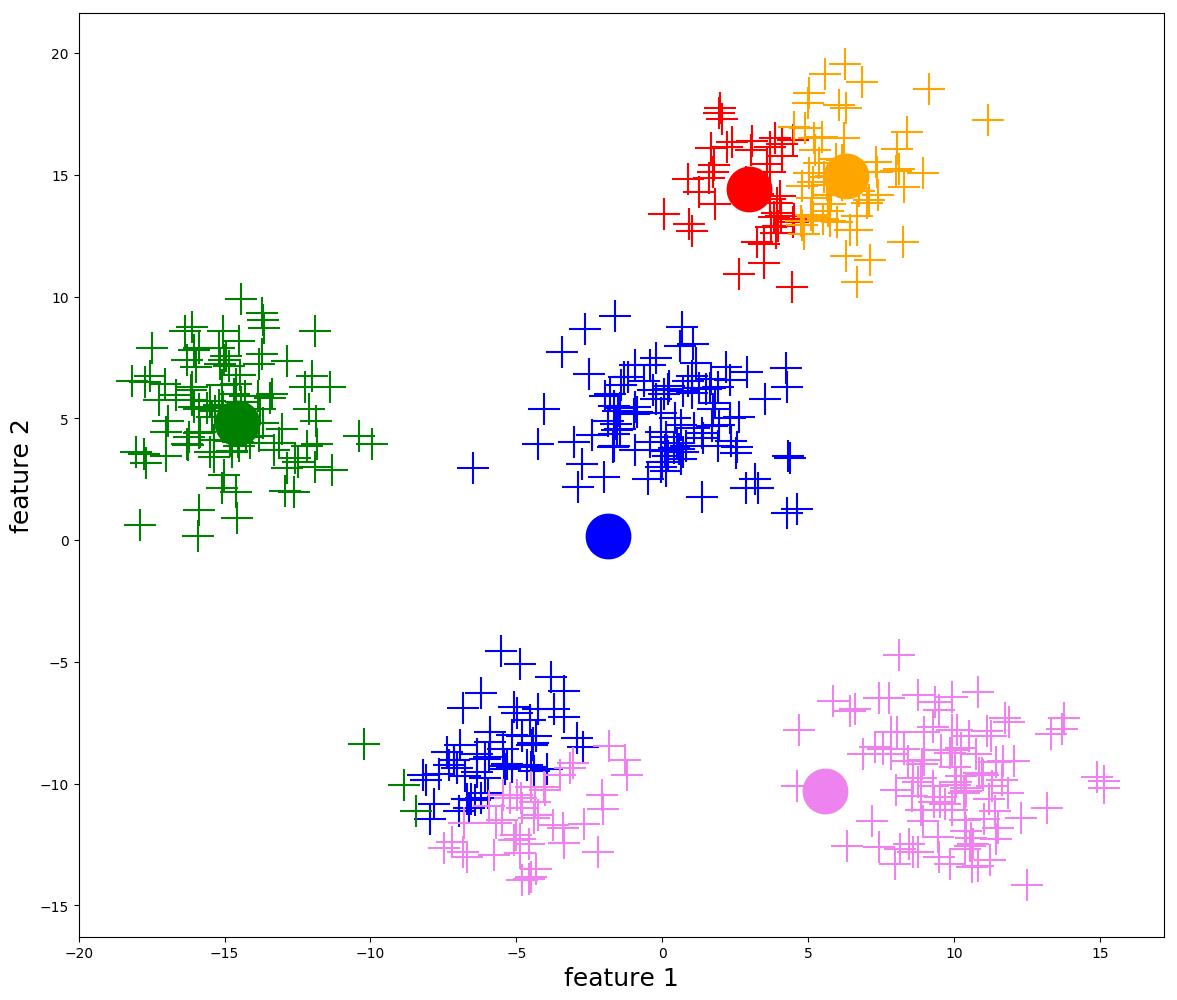

- 군집화에서 가장 일반적으로 사용되는 알고리즘
- 중심점(centroid)을 선택해, 그 중심에 가장 가까운 데이터들을 묶어나가는 기법
- 군집을 중심점 하나로 대표하므로 중심(평균)을 구할 수 없는 데이터에는 쓸 수 없음

**1) k-means의 주요 단계**

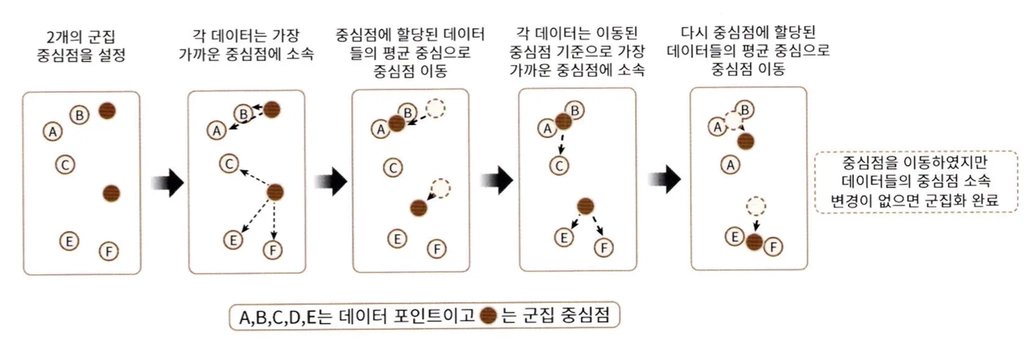

**2) k-means의 장단점**
- 장점
    - 직관적이고 구현이 쉬움
    - 대용량 데이터에도 적용 가능
- 단점
    - 초기 centroid에 민감 → `k-means++`로 완화
    - 군집 수 k 결정이 어려움 → 엘보우 방법, 실루엣 계수로 탐색
    - 아웃라이어에 민감: 평균 기반이라 이상치 하나가 중심을 왜곡
    - 기하학적인 모양의 군집은 파악하기 어려움 → 길쭉하거나 초승달 모양이면 실패

**3) 엘보우 방법**

- 클러스터 내 SSE를 바탕으로 그래프를 활용해 최적 클러스터 개수 k를 추정하는 방법

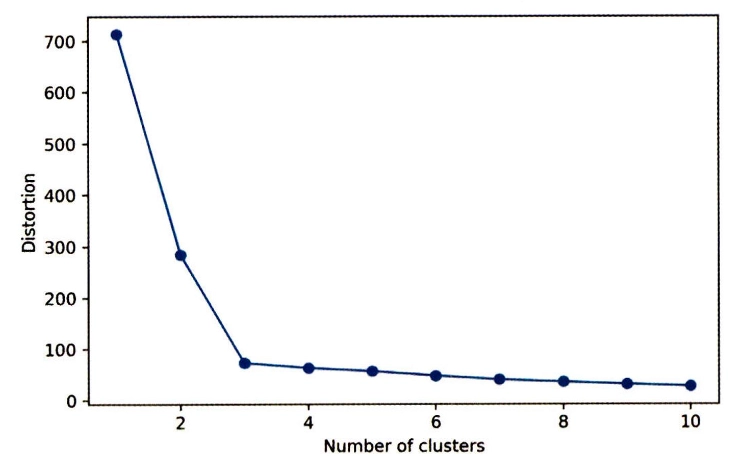

- 급격히 기울기가 변하는 지점(팔꿈치)이 최적의 k
- 장점: 직관적이고 구현이 간단
- 단점: 그래프가 완만하면 팔꿈치가 어디인지 주관이 개입. 데이터에 따라 아예 안 보이기도 함

### 3-3. DBSCAN

- DBSCAN : 밀도가 높은 지역의 데이터를 하나의 군집으로 묶고, 밀도 기준을 만족하지 못하는 점은 군집에 포함시키지 않는 군집화 알고리즘
- k-means는 k를 정해줘야 하고, 이상치에 휘둘리고, 원형만 잘 잡는 반면, DBSCAN은 이 셋을 정면으로 방어
> k를 안 정해도 되고, 이상치를 따로 빼고, 모양을 안 가림

**1) DBSCAN의 특징**
- 명시적으로 이상치를 지정하여 클러스터링에서 제외
- 다른 알고리즘 대비 이상치로부터 자유로움
- 어떤 데이터가 여러 군집의 특정 거리 내에 있으면 가장 밀도가 높은 군집과 그룹화

**2) DBSCAN 알고리즘의 주요 단계**
- 1단계: 샘플 분류
   - 핵심 샘플 (Core Point) — 반경 ε 안의 이웃이 지정된 개수(MinPts) 이상
   - 경계 샘플 (Border Point) — ε 이내 이웃은 부족하지만, 다른 핵심 샘플의 ε 안에 있음
   - 잡음 샘플 (Noise Point) — 위 둘 다 아닌 나머지 전부

- 2단계: 클러스터 생성 
   - 핵심 샘플들을 ε로 연결한 그룹을 클러스터로 생성
- 3단계: 경계 샘플 할당 
   - 경계 샘플을 해당 핵심 샘플의 클러스터에 할당

**3) DBSCAN의 장단점**
- 장점
   - 클러스터 모양을 원형으로 가정하지 않음 → 임의의 기하학적 분포도 잘 처리
   - 이상치에 민감하지 않음 : Noise를 통해 Outlier 검출이 가능
   - 모든 샘플을 클러스터에 할당하지 않음
- 단점
   - eps와 min_samples 설정에 많은 영향을 받음 (조절에 도메인 지식 필요)
   - 연산량이 많아 속도가 느림
   - 밀도가 서로 다른 군집들은 잘 잡지 못함


### 3-4. Gaussian Mixture Model (GMM)
- 데이터가 여러 다른 모양의 가우시안 분포로 구성되었다고 가정하고, 각 분포를 클러스터로 인식하는 군집화 방법

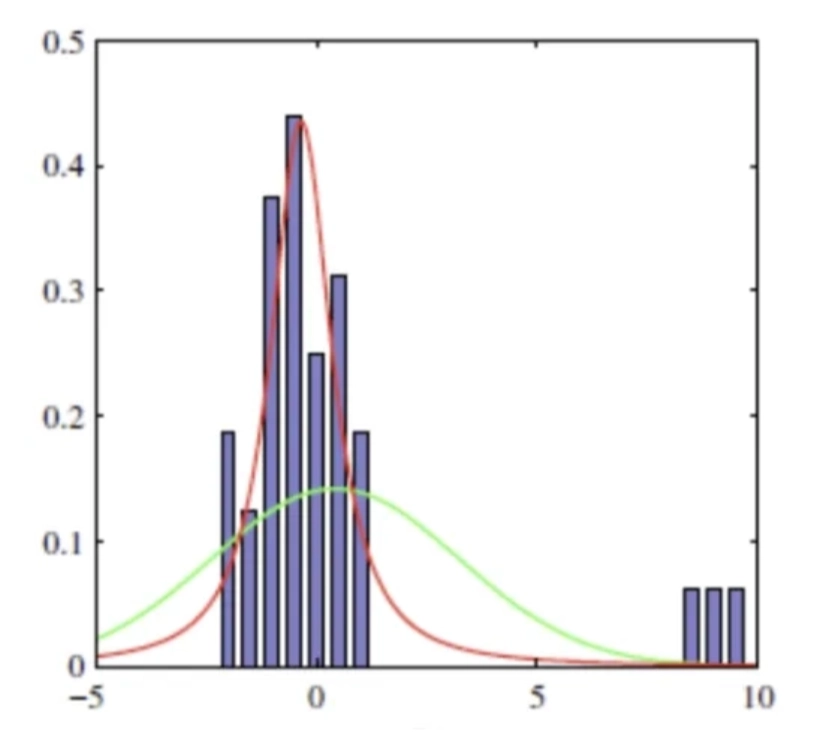

- GMM의 기본 아이디어
   - 단일 분포로 표현하기 어려운 복잡한 확률 분포를 여러 개의 가우시안 분포를 합쳐서 표현하자
- GMM의 특징
   - 모델 기반 군집화(Model-based Clustering) — 데이터를 생성하는 통계적 모델을 가정
   - 각 군집을 확률 분포로 간주, 전체를 여러 확률 분포의 혼합으로 모델링
   - 데이터의 생성 메커니즘까지 모델링 가능

**k-means와 비교**
| 구분 | K-means | GMM |
|---|---|---|
| 기반 | 중심 기반 | 확률 분포 기반 |
| 할당 방식 | 딱 하나의 군집 (hard) | 확률로 분산 할당 (soft) |
| 장점 | 원형 분포에 매우 효과적 / 빠른 수행 속도 | 다양한 데이터셋에 유연 / 길쭉하거나 겹친 분포도 준수하게 처리 |
| 단점 | 길쭉한 분포에서 최적화 어려움 | 오래 걸림 / 정규분포 가정 필요 |

### 3-5 어떤 알고리즘을 고를까

| 이런 상황이면 | 이걸 쓴다 | 왜 |
|---|---|---|
| 몇 개로 나눠야 할지 감이 안 온다 | 계층적 군집화 | 덴드로그램을 그려놓고 나중에 자를 위치를 고르면 됨 |
| 군집이 대체로 동글동글하고 데이터가 크다 | K-means | 빠르고 직관적. 대용량에서도 무리 없음 |
| 군집 모양이 길쭉하거나 서로 겹친다 | GMM | 타원형·중첩 구조를 확률로 처리 |
| 이상치를 골라내는 게 목적이다 | DBSCAN | 이상치에 -1을 붙여 명시적으로 분리 |
| 군집 모양이 초승달·소용돌이처럼 이상하다 | DBSCAN | 모양을 가정하지 않고 밀도로만 판단 |
| 군집마다 밀도가 제각각이다 | HDBSCAN | DBSCAN의 단일 밀도 기준 한계를 보완 |
| 경계에 걸친 데이터의 애매함까지 알고 싶다 | GMM | `predict_proba`로 소속 확률을 반환 |

## 4. 군집화 평가 방법

### 4-1. 외부 평가와 내부 평가

**1) 외부 평가 (External Evaluation)**
- 데이터에 정답 레이블이 존재하는 경우에 사용
- 군집화 결과와 실제 레이블을 비교하여 얼마나 유사한지 평가

**2) 내부 평가 (Internal Evaluation)**

- 정답 레이블이 없는 경우에 사용 (군집화에서는 보통 이쪽)
- 군집 내부 응집도(cohesion)와 군집 간 분리도(separation)를 기반으로 품질을 정량화
   -  데이터 자체의 구조를 기반으로 판단
- 알고리즘별 내부 지표 : k-means는 SSE 최소화, GMM은 로그 우도 최대화
- 범용 지표 : 실루엣 계수, 던 지수

### 4-2. 실루엣 계수

- 클러스터 내 샘플들이 얼마나 조밀하게 모여 있는지를 측정하는 도구로, 이를 통해 군집의 품질을 확인할 수 있음

**1) 실루엣 계수 계산**
- 응집도 a
   - 샘플과 동일한 클러스터 내 다른 포인트들과의 평균 거리
   - 같은 군집 내 데이터가 얼마나 가까이 모여 있는지를 의미
- 분리도 b
   - 샘플과 가장 가까운 다른 클러스터의 샘플들과의 평균 거리
   - 다른 군집과 얼마나 잘 분리되어 있는지를 의미
- 실루엣 계수 s
   - 분리도에서 응집도를 뺀 값을 둘 중 큰 값으로 나눈 값

- 해석
   - a가 작을수록 같은 군집 내 데이터끼리 가까움
   - b가 클수록 다른 군집과 멀리 떨어져 있음
   - 따라서 같은 군집 내에서는 가깝고, 다른 군집과는 멀수록 실루엣 계수가 커짐


**2) 실루엣 계수 해석**
| 조건 | 계수 값 | 의미 | 평가 |
|---|---|---|---|
| 분리도 > 응집도 | 1에 가까움 | 자신의 클러스터에 잘 속해 있고, 다른 클러스터와는 멀리 떨어져 있음 | 군집화가 잘 됨 |
| 분리도 = 응집도 | 0에 가까움 | 클러스터 경계에 위치해 군집 간 거리가 모호 | 분리가 명확하지 않음 |
| 분리도 < 응집도 | -1에 가까움 | 잘못된 클러스터에 할당되어 군집이 섞여 있는 상태 | 군집화가 잘못됨 |

### 4-3. Dunn Index

- 클러스터 간 최소 거리(분리도)와 클러스터 내 최대 거리(응집도)의 비율로 클러스터링 품질을 평가하는 지표

**1) Dunn Index 해석**
- 값이 클수록 좋은 군집화 → 군집 간 거리는 크고(분리도↑), 군집 내부 거리는 작을수록(응집도↑) 좋음
- 0 이상의 값을 가지며 상한은 없음
- 실루엣 계수와 함께 종합적으로 판단하는 것을 권장

**2) Dunn Index의 한계**
- 군집 수가 많아질수록 계산 비용이 증가
- 극단적인 값(가장 멀리 떨어진 포인트, 가장 가까운 군집)에 큰 영향을 받음
- 이상치에 민감하게 반응해 수치가 급격히 떨어질 수 있음